# Kicker Strategy - Results

In [2]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats

### Data Import

In [3]:
results = glob.glob("results/*.json")
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", False) #True if successful, False if not successful
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

timestamped_data = pd.concat(file_list, ignore_index=True)
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

timestamped_data['prev_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(1) #shift(1) -> taking the row above
timestamped_data['prev_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(1)
timestamped_data['prev_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(1)
timestamped_data['prev_event'] = timestamped_data.groupby(['game', 'run_id'])['event_type'].shift(1)
timestamped_data['prev_timestamp'] = timestamped_data.groupby(['game', 'run_id'])['timestamp'].shift(1)

#noramlizing the prev_side column for player 2 for side hypotheses
timestamped_data['prev_side_normalized'] = timestamped_data['prev_side']
is_p2 = timestamped_data['prev_player'] == timestamped_data['player_2']
timestamped_data.loc[is_p2, 'prev_side_normalized'] = timestamped_data.loc[is_p2, 'prev_side'].map({'Left': 'Right', 'Right': 'Left'}).fillna(timestamped_data['prev_side'])

#aggregating the data for each round
round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

### Data Overview

In [4]:
timestamped_data.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,is_contact_p1,is_contact_p2,is_shot_p1,is_shot_p2,prev_player,prev_bar,prev_side,prev_event,prev_timestamp,prev_side_normalized
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,...,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,...,True,False,False,False,Diana,Middle1,Middle,contact,2.985530,Middle
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,...,False,True,False,False,Diana,Attack1,Right,contact,3.749828,Right
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,False,False,False,True,Hans,Attack2,Middle,contact,6.102422,Middle
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,...,True,False,False,False,Hans,NaN,NaN,shot,10.453081,NaN


In [5]:
round_data.head()

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2


# 4. Core Results

## 4.1 Ball Control and Pacing Dynamics

### 4.1.1 Plots and Results

### 4.1.2 Hypotheses

#### Hypothesis 1: Hans holds the ball longer before taking a shot compared to the other players

#### Hypothesis 2: Diana holds the ball shorter before taking a shot compared to the other Players

#### Hypothesis 3: Tanja has a shorter hold time when she is losing compared to when she is Winning

## 4.2 Passing and Playmaking Strategies

### 4.2.1 Plots and Results

#### Passing Direction and Tiki-Taka Results

In [73]:
# Creating possession id for passing analysis
timestamped_data["possession_change"] = (
    (timestamped_data["player"] != timestamped_data["player"].shift()) |
    (timestamped_data["game"] != timestamped_data["game"].shift()) |
    (timestamped_data["run_id"] != timestamped_data["run_id"].shift())
)

timestamped_data["possession_id"] = timestamped_data["possession_change"].cumsum()
timestamped_data["possession_length"] = timestamped_data.groupby("possession_id").cumcount() + 1

# Creating a new dataframe for contact events
contacts = timestamped_data[timestamped_data["event_type"] == "contact"].copy()

# Removing bar numbers to keep the bar names clean
contacts["bar"] = contacts["bar"].str.replace(r"\d+", "", regex=True)

# Get next bar inside the same possession
contacts["next_bar_continued"] = contacts.groupby("possession_id")["bar"].shift(-1)

# Dropping rows where no next bar is available
passing = contacts[contacts["next_bar_continued"].notna()].copy()

passing = passing[["player", "bar", "next_bar_continued", "possession_id"]]
passing.columns = ["player", "from_bar", "to_bar", "possession_id"]

passing.head()

,player,from_bar,to_bar,possession_id
0,Diana,Middle,Attack,1
4,Diana,Middle,Defense,3
5,Diana,Defense,Goal,3
12,Hans,Defense,Goal,6
13,Hans,Goal,Defense,6


In [67]:
# Counting passes per possession
tiki_taka = passing.groupby(["player", "possession_id"]).size().reset_index(name="num_passes")

# Average number of passes per possession for each player
tiki_takas = tiki_taka.groupby("player")["num_passes"].agg(["mean", "median", "max"]).reset_index()
tiki_takas.columns = ["player", "avg_no_pass(tiki-taka)", "median_passes", "max_passes"]

tiki_takas.sort_values("avg_no_pass(tiki-taka)", ascending=False)

,player,avg_no_pass(tiki-taka),median_passes,max_passes
3,Olga,3.174368,2.0,23
2,Magnus,2.166353,2.0,12
5,Tanja,2.073171,2.0,9
4,Simon,2.067472,1.0,16
0,Diana,1.832685,1.0,12
1,Hans,1.729927,1.0,9


In [68]:
# Passing direction analysis
bar_order = {
    "Goal": 1,
    "Defense": 2,
    "Middle": 3,
    "Attack": 4
}

passing["direction"] = passing.apply(
    lambda r: "forward" if bar_order[r["to_bar"]] > bar_order[r["from_bar"]]
    else ("backward" if bar_order[r["to_bar"]] < bar_order[r["from_bar"]] else "same_bar"),
    axis=1
)

direction_pct = passing.groupby(["player", "direction"]).size().unstack(fill_value=0)
direction_pct = direction_pct.div(direction_pct.sum(axis=1), axis=0) * 100

tiki_result_table = direction_pct[["backward", "same_bar"]].copy().round(1)
tiki_result_table["backward_same_sum"] = (
    tiki_result_table["backward"] + tiki_result_table["same_bar"]
).round(1)

tiki_avg = tiki_taka.groupby("player")["num_passes"].mean()
tiki_result_table["avg_passes"] = tiki_avg.round(2)

tiki_result_table.sort_values("avg_passes", ascending=False)

direction,backward,same_bar,backward_same_sum,avg_passes
player,,,,
Olga,39.8,4.4,44.2,3.17
Magnus,54.3,5.2,59.5,2.17
Simon,52.0,6.8,58.8,2.07
Tanja,53.5,7.1,60.6,2.07
Diana,48.1,6.9,55.0,1.83
Hans,52.8,9.5,62.3,1.73


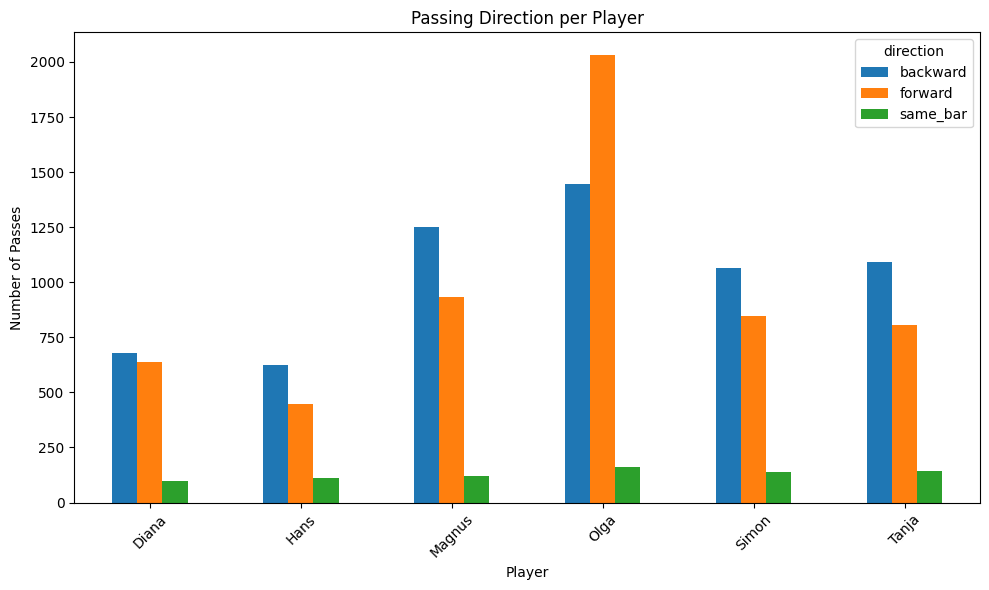

In [69]:
direction_counts = passing.groupby(["player", "direction"]).size().reset_index(name="count")

direction_pivot = direction_counts.pivot(
    index="player",
    columns="direction",
    values="count"
).fillna(0)

direction_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Passing Direction per Player")
plt.xlabel("Player")
plt.ylabel("Number of Passes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Passes Before Shots and Goal Success
hypothesis 4 evidence

In [70]:
# Count number of passes before each shot possession
passes_per_possession = (
    passing.groupby("possession_id")
    .size()
    .reset_index(name="number_of_passes_before_shot")
)

# Keep only shot events
shot_events_passing = timestamped_data[timestamped_data["event_type"] == "shot"].copy()

# Add number of passes before the shot
shot_events_passing = shot_events_passing.merge(
    passes_per_possession,
    on="possession_id",
    how="left"
)

shot_events_passing["number_of_passes_before_shot"] = (
    shot_events_passing["number_of_passes_before_shot"].fillna(0)
)

# Classify shots as direct shots or shots after passes
shot_events_passing["shot_type"] = np.where(
    shot_events_passing["number_of_passes_before_shot"] > 0,
    "After pass",
    "Direct shot"
)

pass_success_table = (
    shot_events_passing
    .groupby("shot_type")
    .agg(
        shots=("is_shot", "sum"),
        goals=("is_goal", "sum")
    )
    .reset_index()
)

pass_success_table["conversion_rate"] = (
    pass_success_table["goals"] / pass_success_table["shots"]
)

pass_success_table["conversion_rate_%"] = (
    pass_success_table["conversion_rate"] * 100
)

pass_success_table.sort_values("conversion_rate", ascending=False)

,shot_type,shots,goals,conversion_rate,conversion_rate_%
0,After pass,3884,897,0.230947,23.094748
1,Direct shot,2482,322,0.129734,12.973409


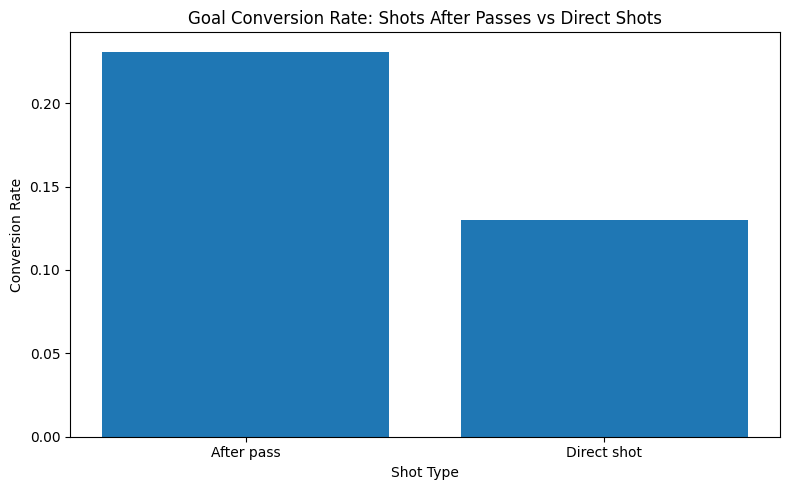

In [71]:
pass_success_table = pass_success_table.sort_values("conversion_rate", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(
    pass_success_table["shot_type"],
    pass_success_table["conversion_rate"]
)

plt.title("Goal Conversion Rate: Shots After Passes vs Direct Shots")
plt.xlabel("Shot Type")
plt.ylabel("Conversion Rate")
plt.tight_layout()

plt.show()

#### Diana Middle-to-Middle Passes and Goal Success
Hypothesis 8 evidence

,shot_type,shots,goals,conversion_rate,conversion_rate_%
0,Without Middle-to-Middle pass,881,205,0.232690,23.269012
1,After Middle-to-Middle pass,63,35,0.555556,55.555556


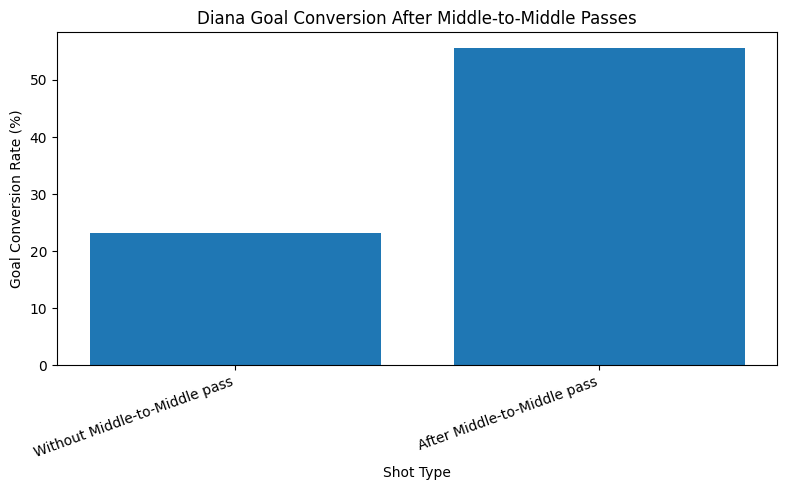

In [75]:
# Hypothesis 8 evidence: Diana middle-to-middle passes and goal success

# Recreate passing data using the same logic from the main notebook
contacts = timestamped_data[timestamped_data["event_type"] == "contact"].copy()
contacts["bar"] = contacts["bar"].str.replace(r"\d+", "", regex=True)
contacts["next_bar_continued"] = contacts.groupby("possession_id")["bar"].shift(-1)

passing = contacts[contacts["next_bar_continued"].notna()].copy()
passing = passing[["player", "bar", "next_bar_continued", "possession_id"]]
passing.columns = ["player", "from_bar", "to_bar", "possession_id"]

# Select Diana's Middle-to-Middle passes
diana_middle_middle_passes = passing[
    (passing["player"] == "Diana") &
    (passing["from_bar"] == "Middle") &
    (passing["to_bar"] == "Middle")
].copy()

# Get possessions where Diana made at least one Middle-to-Middle pass
diana_middle_middle_possessions = diana_middle_middle_passes["possession_id"].unique()

# Select Diana's shot events directly from timestamped_data
diana_shots_h8 = timestamped_data[
    (timestamped_data["player"] == "Diana") &
    (timestamped_data["event_type"] == "shot")
].copy()

# Mark whether Diana's shot happened in a possession with a Middle-to-Middle pass
diana_shots_h8["middle_to_middle_before_shot"] = diana_shots_h8["possession_id"].isin(
    diana_middle_middle_possessions
)

# Create comparison table
diana_middle_pass_table = diana_shots_h8.groupby("middle_to_middle_before_shot").agg(
    shots=("event_type", "count"),
    goals=("is_goal", "sum")
).reset_index()

# Rename groups for easier reading
diana_middle_pass_table["shot_type"] = diana_middle_pass_table["middle_to_middle_before_shot"].map({
    True: "After Middle-to-Middle pass",
    False: "Without Middle-to-Middle pass"
})

# Calculate conversion rate
diana_middle_pass_table["conversion_rate"] = (
    diana_middle_pass_table["goals"] / diana_middle_pass_table["shots"]
)

diana_middle_pass_table["conversion_rate_%"] = (
    diana_middle_pass_table["conversion_rate"] * 100
)

# Clean table order
diana_middle_pass_table = diana_middle_pass_table[
    ["shot_type", "shots", "goals", "conversion_rate", "conversion_rate_%"]
]

display(diana_middle_pass_table)

# Plot conversion rate comparison
plt.figure(figsize=(8, 5))

plt.bar(
    diana_middle_pass_table["shot_type"],
    diana_middle_pass_table["conversion_rate_%"]
)

plt.title("Diana Goal Conversion After Middle-to-Middle Passes")
plt.xlabel("Shot Type")
plt.ylabel("Goal Conversion Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 4.2.2 Hypotheses

#### Hypothesis 4: Passes have a higher goal success rate than direct shots

**H0**: Shots after passes do not have a higher goal success rate than direct shots.

**H1**: Shots after passes have a higher goal success rate than direct shots.

From the result table above, shots after passes have a conversion rate of **23.09%**, while direct shots have a conversion rate of **12.97%**. This already suggests that shots after passes are more successful, but a statistical test is used to check if the difference is significant.


**Statistical Results**

A right-tailed two-proportion Z-test is used to compare the goal conversion rate of shots after passes with the goal conversion rate of direct shots.

The test checks whether the conversion rate after passes is significantly higher than the conversion rate of direct shots.

In [72]:
# Hypothesis 4: Z-test for conversion rate after passes vs direct shots

after_pass_goals = pass_success_table.loc[
    pass_success_table["shot_type"] == "After pass", "goals"
].iloc[0]

after_pass_shots = pass_success_table.loc[
    pass_success_table["shot_type"] == "After pass", "shots"
].iloc[0]

direct_goals = pass_success_table.loc[
    pass_success_table["shot_type"] == "Direct shot", "goals"
].iloc[0]

direct_shots = pass_success_table.loc[
    pass_success_table["shot_type"] == "Direct shot", "shots"
].iloc[0]

successes = [after_pass_goals, direct_goals]
observations = [after_pass_shots, direct_shots]

z_stat, p_value = proportions_ztest(successes, observations, alternative="larger")

print("Hypothesis 4: Shots after passes vs direct shots")
print(f"After pass goals/shots: {after_pass_goals}/{after_pass_shots}")
print(f"Direct shot goals/shots: {direct_goals}/{direct_shots}")
print(f"After pass conversion rate: {(after_pass_goals / after_pass_shots) * 100:.2f}%")
print(f"Direct shot conversion rate: {(direct_goals / direct_shots) * 100:.2f}%")
print(f"z statistic: {z_stat:.4f}")
print(f"p value: {p_value:.4e}")

Hypothesis 4: Shots after passes vs direct shots
After pass goals/shots: 897/3884
Direct shot goals/shots: 322/2482
After pass conversion rate: 23.09%
Direct shot conversion rate: 12.97%
z statistic: 10.0100
p value: 6.8896e-24


The p-value is below 0.05. Therefore, we reject the null hypothesis.

This means that the data provides statistical evidence that shots after passes have a higher goal success rate than direct shots. In this dataset, shots after passes had a conversion rate of **23.09%**, while direct shots had a conversion rate of **12.97%**. This supports the hypothesis that passing before shooting is linked with better offensive success.

#### Hypothesis 5: Olga passes the ball more than the other Players

#### Hypothesis 6: The goal success is higher after a pass on the same bar compared to other passes or direct shots


#### Hypothesis 7: The goal success is higher after back passes (e.g. Attack -> Middle) than after forward passes or direct shots

#### Hypothesis 8: Diana has a higher goal success after a Middle -> Middle pass compared to other passes or direct shots
**H0:** Diana's goal conversion rate after middle-to-middle passes is not higher than her goal conversion rate without middle-to-middle passes.

**H1:** Diana's goal conversion rate after middle-to-middle passes is higher than her goal conversion rate without middle-to-middle passes.

**Statistical Results**

In [76]:
# Hypothesis 8: Two-proportion z-test for Diana's Middle-to-Middle pass success

# Get values from the Diana middle pass table
after_middle_pass = diana_middle_pass_table[
    diana_middle_pass_table["shot_type"] == "After Middle-to-Middle pass"
]

without_middle_pass = diana_middle_pass_table[
    diana_middle_pass_table["shot_type"] == "Without Middle-to-Middle pass"
]

# Number of goals
goals_after_middle_pass = after_middle_pass["goals"].iloc[0]
goals_without_middle_pass = without_middle_pass["goals"].iloc[0]

# Number of shots
shots_after_middle_pass = after_middle_pass["shots"].iloc[0]
shots_without_middle_pass = without_middle_pass["shots"].iloc[0]

# Two-proportion z-test
count = [goals_after_middle_pass, goals_without_middle_pass]
nobs = [shots_after_middle_pass, shots_without_middle_pass]

z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative="larger"
)

h8_results = pd.DataFrame({
    "comparison": ["After Middle-to-Middle pass vs Without Middle-to-Middle pass"],
    "goals_after_middle_pass": [goals_after_middle_pass],
    "shots_after_middle_pass": [shots_after_middle_pass],
    "goals_without_middle_pass": [goals_without_middle_pass],
    "shots_without_middle_pass": [shots_without_middle_pass],
    "z_statistic": [round(z_stat, 4)],
    "p_value": [round(p_value, 4)]
})

display(h8_results)

,comparison,goals_after_middle_pass,shots_after_middle_pass,goals_without_middle_pass,shots_without_middle_pass,z_statistic,p_value
0,After Middle-to-Middle pass vs Without Middle-...,35,63,205,881,5.6856,0.0


**Interpretation**

The results show that Diana scored 35 goals from 63 shots after a middle-to-middle pass. This gives a conversion rate of about 55.6%.

Without a middle-to-middle pass, Diana scored 205 goals from 881 shots. This gives a conversion rate of about 23.3%.

The two-proportion z-test gives a z-statistic of 5.6856 and a p-value of 0.0000. Since the p-value is below 0.05, we reject the null hypothesis.

This means there is statistical evidence that Diana has a higher goal conversion rate after middle-to-middle passes compared with shots without middle-to-middle passes.

## 4.3 Shot Execution and Offensive Efficiency

### 4.3.1 Plots and Results

#### Shot Conversion Rate

In [6]:
player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])
player_conversion_rate.sort_values(by='conversion_rate', ascending=False)

,player,shots,goals,conversion_rate
3,Olga,664,223,0.335843
0,Diana,944,240,0.254237
2,Magnus,1002,186,0.185629
5,Tanja,1141,189,0.165644
4,Simon,1368,219,0.160088
1,Hans,1247,162,0.129912


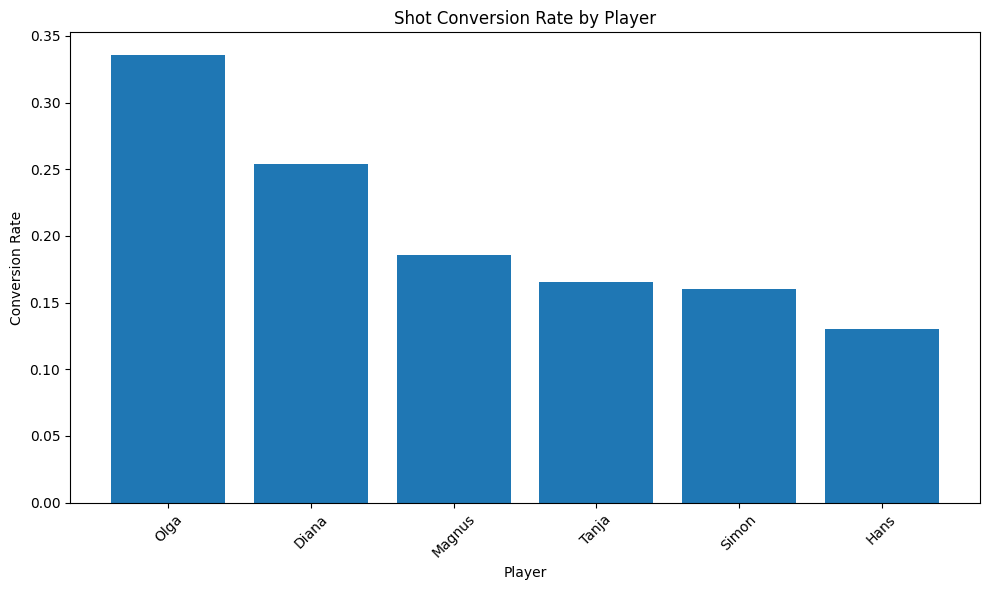

In [19]:
player_conversion_rate = player_conversion_rate.sort_values(
    by='conversion_rate',
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    player_conversion_rate['player'],
    player_conversion_rate['conversion_rate'])

plt.title('Shot Conversion Rate by Player')
plt.xlabel('Player')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4.3.2 Hypotheses

#### Hypothesis 9: Olga demonstrates the highest shot conversion rate.

H0: There is no statistically significant difference between Olga's shot conversion rate and the conversion rate of the other players.

H1: Olga has a statistically significant higher shot conversion rate compared to the other players.

In [15]:
scaler = StandardScaler()
scaler.fit(player_conversion_rate["conversion_rate"].values.reshape(-1, 1))
z_scores = scaler.transform(player_conversion_rate["conversion_rate"].values.reshape(-1, 1))
player_conversion_rate["z_score"] = z_scores
player_conversion_rate.sort_values(by="z_score", ascending=False)

,player,shots,goals,conversion_rate,z_score
3,Olga,664,223,0.335843,1.874807
0,Diana,944,240,0.254237,0.703484
2,Magnus,1002,186,0.185629,-0.281280
5,Tanja,1141,189,0.165644,-0.568126
4,Simon,1368,219,0.160088,-0.647880
1,Hans,1247,162,0.129912,-1.081006


Olga's conversion rate is almost 1.9 standard deviations above the group mean.

Statistical results:

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Olga}}$ as the shot conversion rate (proportion of goals to total shots) of Olga and $p_{\text{Others}}$ as the aggregated shot conversion rate of the other players.

$$H_0: p_{\text{Olga}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Olga}} > p_{\text{Others}}$$

In [17]:
olga_goals = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_goal'].sum()
olga_shots = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_shot'].sum()

others_goals = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_goal'].sum()
others_shots = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_shot'].sum()

goals = [olga_goals, others_goals]
observations = [olga_shots, others_shots]

z_stat, p_value = proportions_ztest(goals, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 8.4981e-24


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 10: Players who have a attack bias scores a higher number of goals compared to the other players.

**H0**: There is no statistically significant correlation between attack bias and goals scored by players.

**H1**: Players have a statistically significant positive correlation between attack bias and goal scored.

In [11]:
# Extracting attack specific data 
group_cols = ["player", "game"] 
contacts = timestamped_data[timestamped_data["event_type"] == "contact"]
total_contacts = contacts.groupby(group_cols).size()
attack_contact = contacts[contacts["bar"].str.contains("Attack", na=False)].groupby(group_cols).size()  # strips Attack1 to Attack
# We need 2 main  features 'Attack Bias' & 'Total Goals'
attack_bias = (attack_contact / total_contacts).rename("attack_bias").fillna(0)
goals = timestamped_data[(timestamped_data["event_type"] == "shot") & (timestamped_data["is_goal"] == True)]
total_goals = goals.groupby(group_cols).size().rename("total_goals")
player_h2 = pd.concat([attack_bias,total_goals], axis=1).fillna(0)
# Testing the co-relation using stats.pearson

correlation, p_value = stats.pearsonr(player_h2['attack_bias'], player_h2['total_goals'])

print(f"p_value = {p_value:.4f}")
print(correlation)


p_value = 0.5357
0.11768859471281078


In [11]:
player_h2

attack_bias  total_goals
player game                                  
Diana  Diana-Hans       0.225806           50
       Diana-Magnus     0.233937           45
       Diana-Olga       0.257658           50
       Diana-Simon      0.257603           45
       Diana-Tanja      0.227941           50
Hans   Diana-Hans       0.154008           24
       Hans-Magnus      0.221311           35
       Hans-Olga        0.219959           30
       Hans-Simon       0.231237           27
       Hans-Tanja       0.220109           46
Magnus Diana-Magnus     0.172596           33
       Hans-Magnus      0.197115           50
       Magnus-Olga      0.227053           33
       Magnus-Simon     0.207273           35
       Magnus-Tanja     0.204268           35
Olga   Diana-Olga       0.188488           35
       Hans-Olga        0.186457           49
       Magnus-Olga      0.203640           44
       Olga-Simon       0.217687           45
       Olga-Tanja       0.182416           50
Simon  Diana-Simon      0.139183           36
       Hans-Simon       0.153153           50
       Magnus-Simon     0.184874           47
       Olga-Simon       0.171390           42
       Simon-Tanja      0.155828           44
Tanja  Diana-Tanja      0.187402           30
       Hans-Tanja       0.173505           47
       Magnus-Tanja     0.185065           38
       Olga-Tanja       0.215262           35
       Simon-Tanja      0.209268           39

Statistical Results:
With a p-value of $0.54$, the results are not statistically significant ($p > 0.05$). 

Therefore, we cannot reject the null hypothesis. There is no evidence in this data to support the claim that a higher attack bias leads to a greater number of goals.

#### Hypothesis 11: Diana shoots more shots from the left side than the other players

H0: There is no significant difference in the amount of shots taken from the left side for Olga compared to the other players

H1: Olga takes significantly more shots from the left side than the other players.

In [12]:
player_side_percentages = timestamped_data[timestamped_data['is_shot']].groupby('player')['prev_side_normalized'].value_counts(normalize=True).reset_index(name='percentage')
player_side_percentages['percentage'] = player_side_percentages['percentage'] * 100

left_side_shots = player_side_percentages[player_side_percentages['prev_side_normalized'] == 'Left']
left_side_shots.sort_values(by='percentage', ascending=False)

,player,prev_side_normalized,percentage
0,Diana,Left,66.313559
5,Hans,Left,27.826784
8,Magnus,Left,26.746507
14,Simon,Left,26.096491
11,Olga,Left,23.945783
17,Tanja,Left,21.472393


In [13]:
scaler = StandardScaler()
scaler.fit(left_side_shots["percentage"].values.reshape(-1, 1))
z_scores = scaler.transform(left_side_shots["percentage"].values.reshape(-1, 1))
left_side_shots["z_score"] = z_scores
left_side_shots.sort_values(by="z_score", ascending=False)

,player,prev_side_normalized,percentage,z_score
0,Diana,Left,66.313559,2.216034
5,Hans,Left,27.826784,-0.274371
8,Magnus,Left,26.746507,-0.344274
14,Simon,Left,26.096491,-0.386335
11,Olga,Left,23.945783,-0.525503
17,Tanja,Left,21.472393,-0.685551


Diana takes two thirds of shots from the left side.

Olga's amount of shots taken from the left side are more than two standard deviations above the group mean.

### Statistical Results


We're using a right-tailed Z-test for proportions.

We define $p_{\text{Diana}}$ as the proportion of shots taken from the left side by Diana and $p_{\text{Others}}$ as the aggregated proportion of shots taken from the left side by the other players.

$$H_0: p_{\text{Diana}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Diana}} > p_{\text{Others}}$$

In [14]:
diana_left = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
diana_total_shots = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

others_left = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
others_total_shots = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

successes = [diana_left, others_left]
observations = [diana_total_shots, others_total_shots]

z_stat, p_value = proportions_ztest(successes, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 3.1260e-138


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 12: Shots taken from defense bar or goal bar have a lower goal conversion rate compared to shots from middle/attack bar

#### Hypothesis 13: Simon and Hans take more shots from the Goal and Defense bar than the other players.

#### Hypothesis 14: Simon is more successful for his long shots than Hans. 

#### Hypothesis 15: Hans has a lower conversion rate ? 

## 4.4 Defensive Behaviour

### 4.4.1 Plots and Results

In [62]:
defensive_bars = ["Goal1", "Goal2", "Defense1", "Defense2"]

# first event after the other player tried a shot
# use timestamped_data because it has next_player and next_bar columns
opponent_recovery_events = timestamped_data[
    (timestamped_data["event_type"] == "shot") &
    (timestamped_data["next_player"].notna()) &
    (timestamped_data["next_player"] != timestamped_data["player"])
].copy()
# if the next event is on Goal or Defense bar, it means defensive recovery
defensive_events = opponent_recovery_events[
    opponent_recovery_events["next_bar"].isin(defensive_bars)
].copy()

defensive_events.head()


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,is_shot,round,is_contact_p1,is_contact_p2,is_shot_p1,is_shot_p2,next_player,next_bar
9,Diana-Hans,0,Diana,Hans,33.182286,Hans,shot,NaN,NaN,False,True,2,False,False,False,True,Diana,Defense1
11,Diana-Hans,0,Diana,Hans,35.235728,Diana,shot,NaN,NaN,False,True,2,False,False,True,False,Hans,Defense2
20,Diana-Hans,0,Diana,Hans,62.824143,Hans,shot,NaN,NaN,False,True,3,False,False,False,True,Diana,Goal1
25,Diana-Hans,0,Diana,Hans,87.752994,Hans,shot,NaN,NaN,False,True,3,False,False,False,True,Diana,Defense1
28,Diana-Hans,0,Diana,Hans,92.440041,Diana,shot,NaN,NaN,False,True,3,False,False,True,False,Hans,Defense2


In [63]:
# count how many defensive events each player made
defended_by_player = (
    defensive_events
    .groupby("next_player")
    .size()
    .reset_index(name="defensive_events")
    .rename(columns={"next_player": "player"})
)

defended_by_player

,player,defensive_events
0,Diana,537
1,Hans,496
2,Magnus,675
3,Olga,586
4,Simon,563
5,Tanja,654


In [64]:
# count how many opponent shots each player faced
shots_faced = (
    opponent_recovery_events
    .groupby("next_player")
    .size()
    .reset_index(name="opponent_shots_faced")
    .rename(columns={"next_player": "player"})
)

shots_faced

,player,opponent_shots_faced
0,Diana,714
1,Hans,619
2,Magnus,869
3,Olga,767
4,Simon,691
5,Tanja,840


In [65]:
# merge defensive events with opponent shots faced
defense_result_table = shots_faced.merge(
    defended_by_player,
    on="player",
    how="left"
)

# replace missing values with 0
defense_result_table["defensive_events"] = defense_result_table["defensive_events"].fillna(0)

# calculate defensive event percentage
defense_result_table["defensive_event_%"] = (
    defense_result_table["defensive_events"] /
    defense_result_table["opponent_shots_faced"] * 100
)

# round and sort
defense_result_table = defense_result_table.round(1)

defense_result_table = defense_result_table.sort_values(
    by="defensive_event_%",
    ascending=False
)

defense_result_table

,player,opponent_shots_faced,defensive_events,defensive_event_%
4,Simon,691,563,81.5
1,Hans,619,496,80.1
5,Tanja,840,654,77.9
2,Magnus,869,675,77.7
3,Olga,767,586,76.4
0,Diana,714,537,75.2


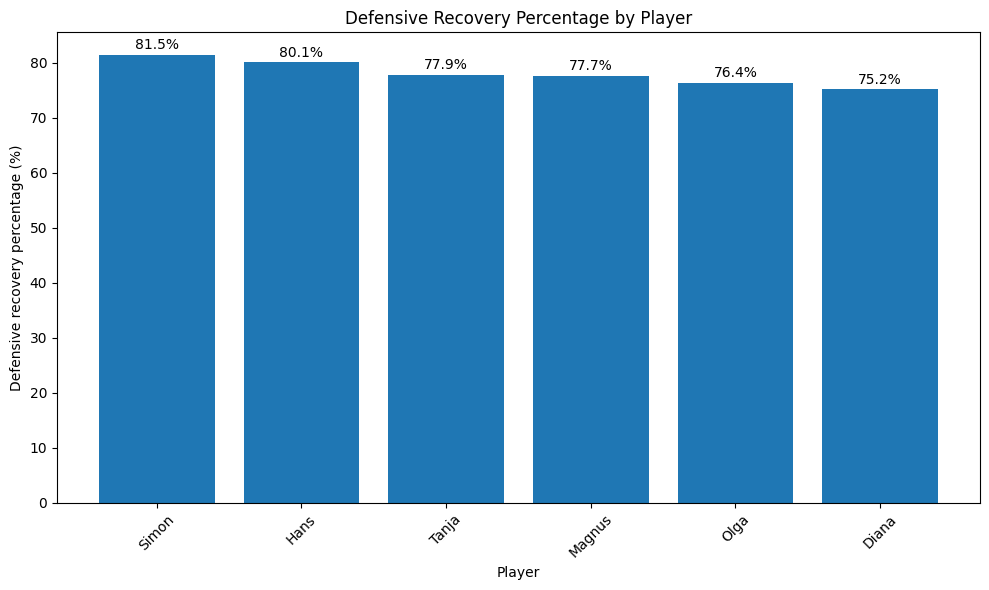

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    defense_result_table["player"],
    defense_result_table["defensive_event_%"]
)

plt.title("Defensive Recovery Percentage by Player")
plt.xlabel("Player")
plt.ylabel("Defensive recovery percentage (%)")
plt.xticks(rotation=45)

for i, value in enumerate(defense_result_table["defensive_event_%"]):
    plt.text(i, value + 1, str(value) + "%", ha="center")

plt.tight_layout()
plt.show()

### 4.4.2 Hypotheses

#### Hypothesis 16: Simon and Magnus have stronger defensive recovery behavior than the other Players
H0: Simon and Magnus do not have a higher defensive recovery rate compared to the other players.

H1: Simon and Magnus have a higher defensive recovery rate compared to the other players.

In [42]:
target_players = ["Simon", "Magnus"]

individual_test_summary = defense_result_table[
    defense_result_table["player"].isin(target_players)
][["player", "defensive_events", "opponent_shots_faced", "defensive_event_%"]]

individual_test_summary

,player,defensive_events,opponent_shots_faced,defensive_event_%
4,Simon,563,691,81.5
2,Magnus,675,869,77.7


In [43]:
individual_test_results = []

for player in ["Simon", "Magnus"]:
    player_events = defense_result_table.loc[
        defense_result_table["player"] == player, "defensive_events"
    ].iloc[0]
    
    player_shots = defense_result_table.loc[
        defense_result_table["player"] == player, "opponent_shots_faced"
    ].iloc[0]
    
    other_events = defense_result_table.loc[
        defense_result_table["player"] != player, "defensive_events"
    ].sum()
    
    other_shots = defense_result_table.loc[
        defense_result_table["player"] != player, "opponent_shots_faced"
    ].sum()
    
    count = np.array([player_events, other_events])
    nobs = np.array([player_shots, other_shots])
    
    z_stat, p_value = proportions_ztest(
        count,
        nobs,
        alternative="larger"
    )
    
    individual_test_results.append({
        "player": player,
        "player_defensive_events": player_events,
        "player_opponent_shots_faced": player_shots,
        "player_defensive_rate_%": (player_events / player_shots) * 100,
        "others_defensive_rate_%": (other_events / other_shots) * 100,
        "z_statistic": z_stat,
        "p_value": p_value
    })

individual_test_results = pd.DataFrame(individual_test_results)

individual_test_results.round(4)

,player,player_defensive_events,player_opponent_shots_faced,player_defensive_rate_%,others_defensive_rate_%,z_statistic,p_value
0,Simon,563,691,81.4761,77.3956,2.3831,0.0086
1,Magnus,675,869,77.6755,78.1052,-0.2748,0.6083


For Simon, the defensive recovery rate is 81.48%, while the defensive recovery rate of the other players is 77.40%. The p-value is 0.0086, which is below 0.05. This means Simon has a significantly higher defensive recovery rate than the other players.

For Magnus, the defensive recovery rate is 77.68%, while the defensive recovery rate of the other players is 78.11%. The p-value is 0.6083, which is above 0.05. This means Magnus does not have a significantly higher defensive recovery rate than the other players.
The hypothesis is supported for Simon, but not supported for Magnus.

#### Hypothesis 17: Players with higher defensive recovery rates win more games

#### Hypothesis 18: The other players have a higher shot-conversion rate when playing against Hans.

## 4.5 Matchup-Specific Patterns

### 4.5.1 Plots and Results

### 4.5.2 Hypotheses

#### Hypothesis 19: Magnus wins less against Hans than against anyone else

#### Hypothesis 20: Games for Diana and Hans have less events than the games for the other matchups.

----------------------------